# Лабораторная работа №2: прогнозирование временного ряда NMDB методом ближайших соседей

**Станция:** Тикси (TXBY)  
**Период:** 20-29 сентября 2015 года  
**Разрешение:** 1 минута, UTC  
**Длина вектора-истории:** `m = 180` отсчетов  
**Число соседей:** `k = 4`  
**Горизонт прогноза:** 180 минут

Источник данных: [NMDB NEST](https://www.nmdb.eu/nest/). Пропуски заполняются медианой наблюдаемых значений.


## Загрузка данных из NMDB NEST

Из ASCII-ответа NEST извлекаются минутные значения RCORR_E для станции TXBY.


In [11]:
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

try:
    from IPython.display import display
except ImportError:
    display = print

ROOT = Path.cwd()
url = (
    "https://www.nmdb.eu/nest/draw_graph.php?formchk=1&stations[]=TXBY"
    "&tabchoice=revori&dtype=corr_for_efficiency&tresolution=0&yunits=0"
    "&date_choice=bydate&start_day=20&start_month=9&start_year=2015"
    "&start_hour=0&start_min=0&end_day=29&end_month=9&end_year=2015"
    "&end_hour=23&end_min=59&output=ascii"
)

response = requests.get(url, timeout=60)
response.raise_for_status()
data_lines = [
    line.strip()
    for line in response.text.splitlines()
    if line[:4].isdigit() and ";" in line
]
df = pd.read_csv(
    StringIO("\n".join(data_lines)),
    sep=";",
    names=["datetime", "corr_for_efficiency"],
)
df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
df["corr_for_efficiency"] = pd.to_numeric(
    df["corr_for_efficiency"], errors="coerce"
)
df = (
    df.dropna()
    .sort_values("datetime")
    .drop_duplicates("datetime")
    .reset_index(drop=True)
)
print(f"Загружено корректных наблюдений: {len(df)}")
df.head(10)


Загружено корректных наблюдений: 14032


,datetime,corr_for_efficiency
0,2015-09-20 00:00:00+00:00,90.800
1,2015-09-20 00:01:00+00:00,96.267
2,2015-09-20 00:02:00+00:00,92.800
3,2015-09-20 00:03:00+00:00,93.867
4,2015-09-20 00:04:00+00:00,92.933
5,2015-09-20 00:05:00+00:00,94.400
6,2015-09-20 00:06:00+00:00,95.333
7,2015-09-20 00:07:00+00:00,92.933
8,2015-09-20 00:08:00+00:00,94.667
9,2015-09-20 00:09:00+00:00,92.800


## Подготовка временного ряда

Восстанавливается полная минутная сетка. Только отсутствующие измерения заменяются медианой доступных значений; выбросы не ищутся и не изменяются.


In [12]:
start = pd.Timestamp("2015-09-20 00:00:00", tz="UTC")
end = pd.Timestamp("2015-09-29 23:59:00", tz="UTC")
full_index = pd.date_range(start, end, freq="min")

series = df.set_index("datetime")["corr_for_efficiency"].reindex(full_index)
series.index.name = "datetime"
missing_mask = series.isna()
median_value = series.dropna().median()
filled_series = series.fillna(median_value)

assert filled_series.notna().all(), "После заполнения не должно остаться пропусков"

data_summary = pd.DataFrame(
    {
        "Показатель": [
            "Полный минутный ряд",
            "Полученные наблюдения",
            "Пропуски",
            "Заполнено медианой",
            "Медиана",
        ],
        "Количество / значение": [
            len(full_index),
            int(series.notna().sum()),
            int(missing_mask.sum()),
            int(missing_mask.sum()),
            median_value,
        ],
    }
)
display(data_summary.style.format({"Количество / значение": "{:.3f}"}))
print(f"Пропусков после заполнения: {filled_series.isna().sum()}")


,Показатель,Количество / значение
0,Полный минутный ряд,14400.000
1,Полученные наблюдения,14032.000
2,Пропуски,368.000
3,Заполнено медианой,368.000
4,Медиана,86.133


Пропусков после заполнения: 0


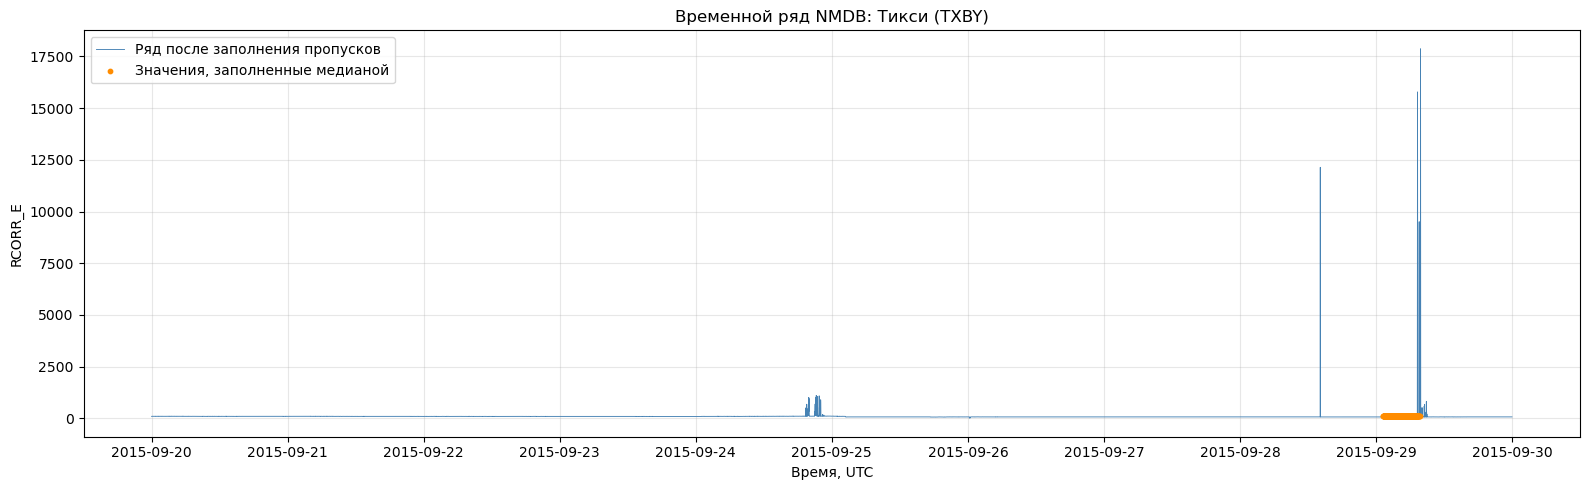

In [13]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(filled_series.index, filled_series, linewidth=0.65, color="steelblue", label="Ряд после заполнения пропусков")
ax.scatter(
    series.index[missing_mask],
    filled_series[missing_mask],
    s=10,
    color="darkorange",
    label="Значения, заполненные медианой",
    zorder=3,
)
ax.set_title("Временной ряд NMDB: Тикси (TXBY)")
ax.set_xlabel("Время, UTC")
ax.set_ylabel("RCORR_E")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(ROOT / "series_with_filled_gaps.png", dpi=160, bbox_inches="tight")
plt.show()


## Формирование векторов-историй

Последние 180 значений являются тестовым вектором. Для каждого исторического окна сохраняется следующий за ним фрагмент длиной 180 минут. Исторические окна и их следующие фрагменты заканчиваются до начала тестового окна, поэтому данные тестовой точки не попадают в обучение.


In [14]:
m = 180
k = 4
forecast_horizon = 180
values = filled_series.to_numpy(dtype=float)
n_values = len(values)

test_start = n_values - m
test_vector = values[test_start:]
candidate_starts = np.arange(test_start - m - forecast_horizon + 1)

if len(candidate_starts) < k:
    raise ValueError("Недостаточно исторических векторов для поиска соседей")

history_vectors = np.stack([values[i : i + m] for i in candidate_starts])
future_vectors = np.stack(
    [values[i + m : i + m + forecast_horizon] for i in candidate_starts]
)

assert test_vector.shape == (m,)
assert history_vectors.shape[1] == m
assert future_vectors.shape[1] == forecast_horizon
assert candidate_starts[-1] + m + forecast_horizon <= test_start

print(f"Число исторических векторов: {len(history_vectors)}")
print(f"Размер тестового вектора: {test_vector.shape[0]}")
print(f"Горизонт прогноза: {forecast_horizon} минут")
print(f"Тестовый интервал: {full_index[test_start]} - {full_index[-1]}")


Число исторических векторов: 13861
Размер тестового вектора: 180
Горизонт прогноза: 180 минут
Тестовый интервал: 2015-09-29 21:00:00+00:00 - 2015-09-29 23:59:00+00:00


## Поиск ближайших соседей

Тестовый вектор сравнивается со всеми историческими векторами по евклидовой, манхэттенской метрикам и метрике Чебышёва. Для каждой метрики выбираются четыре вектора с наименьшими расстояниями.


In [15]:
differences = history_vectors - test_vector
distances = {
    "Евклидова": np.sqrt(np.sum(differences ** 2, axis=1)),
    "Манхэттенская": np.sum(np.abs(differences), axis=1),
    "Чебышёва": np.max(np.abs(differences), axis=1),
}

neighbor_indices = {}
neighbor_tables = {}
predictions = {}
summary_rows = []

for metric_name, metric_distances in distances.items():
    selected = np.argsort(metric_distances, kind="stable")[:k]
    neighbor_indices[metric_name] = selected
    predictions[metric_name] = future_vectors[selected].mean(axis=0)

    starts = candidate_starts[selected]
    table = pd.DataFrame(
        {
            "Метрика": metric_name,
            "Ранг": np.arange(1, k + 1),
            "Расстояние": metric_distances[selected],
            "Начало истории": full_index[starts],
            "Конец истории": full_index[starts + m - 1],
            "Начало следующего фрагмента": full_index[starts + m],
            "Конец следующего фрагмента": full_index[starts + m + forecast_horizon - 1],
        }
    )
    neighbor_tables[metric_name] = table
    summary_rows.append(
        {
            "Метрика": metric_name,
            "Минимальное расстояние": metric_distances[selected[0]],
            "Среднее прогноза": predictions[metric_name].mean(),
            "Минимум прогноза": predictions[metric_name].min(),
            "Максимум прогноза": predictions[metric_name].max(),
        }
    )

neighbors_summary = pd.concat(neighbor_tables.values(), ignore_index=True)
forecast_summary = pd.DataFrame(summary_rows)
display(neighbors_summary.style.format({"Расстояние": "{:.3f}"}))
display(forecast_summary.style.format({
    "Минимальное расстояние": "{:.3f}",
    "Среднее прогноза": "{:.3f}",
    "Минимум прогноза": "{:.3f}",
    "Максимум прогноза": "{:.3f}",
}))


,Метрика,Ранг,Расстояние,Начало истории,Конец истории,Начало следующего фрагмента,Конец следующего фрагмента
0,Евклидова,1,20.951,2015-09-27 22:05:00+00:00,2015-09-28 01:04:00+00:00,2015-09-28 01:05:00+00:00,2015-09-28 04:04:00+00:00
1,Евклидова,2,21.257,2015-09-28 04:57:00+00:00,2015-09-28 07:56:00+00:00,2015-09-28 07:57:00+00:00,2015-09-28 10:56:00+00:00
2,Евклидова,3,21.442,2015-09-29 13:53:00+00:00,2015-09-29 16:52:00+00:00,2015-09-29 16:53:00+00:00,2015-09-29 19:52:00+00:00
3,Евклидова,4,21.463,2015-09-27 22:46:00+00:00,2015-09-28 01:45:00+00:00,2015-09-28 01:46:00+00:00,2015-09-28 04:45:00+00:00
4,Манхэттенская,1,219.465,2015-09-26 20:34:00+00:00,2015-09-26 23:33:00+00:00,2015-09-26 23:34:00+00:00,2015-09-27 02:33:00+00:00
5,Манхэттенская,2,225.068,2015-09-27 13:28:00+00:00,2015-09-27 16:27:00+00:00,2015-09-27 16:28:00+00:00,2015-09-27 19:27:00+00:00
6,Манхэттенская,3,225.597,2015-09-27 22:05:00+00:00,2015-09-28 01:04:00+00:00,2015-09-28 01:05:00+00:00,2015-09-28 04:04:00+00:00
7,Манхэттенская,4,225.987,2015-09-29 13:53:00+00:00,2015-09-29 16:52:00+00:00,2015-09-29 16:53:00+00:00,2015-09-29 19:52:00+00:00
8,Чебышёва,1,3.600,2015-09-26 01:12:00+00:00,2015-09-26 04:11:00+00:00,2015-09-26 04:12:00+00:00,2015-09-26 07:11:00+00:00
9,Чебышёва,2,3.733,2015-09-28 02:59:00+00:00,2015-09-28 05:58:00+00:00,2015-09-28 05:59:00+00:00,2015-09-28 08:58:00+00:00


,Метрика,Минимальное расстояние,Среднее прогноза,Минимум прогноза,Максимум прогноза
0,Евклидова,20.951,64.531,62.600,66.133
1,Манхэттенская,219.465,64.421,62.367,66.500
2,Чебышёва,3.600,64.737,63.267,66.666


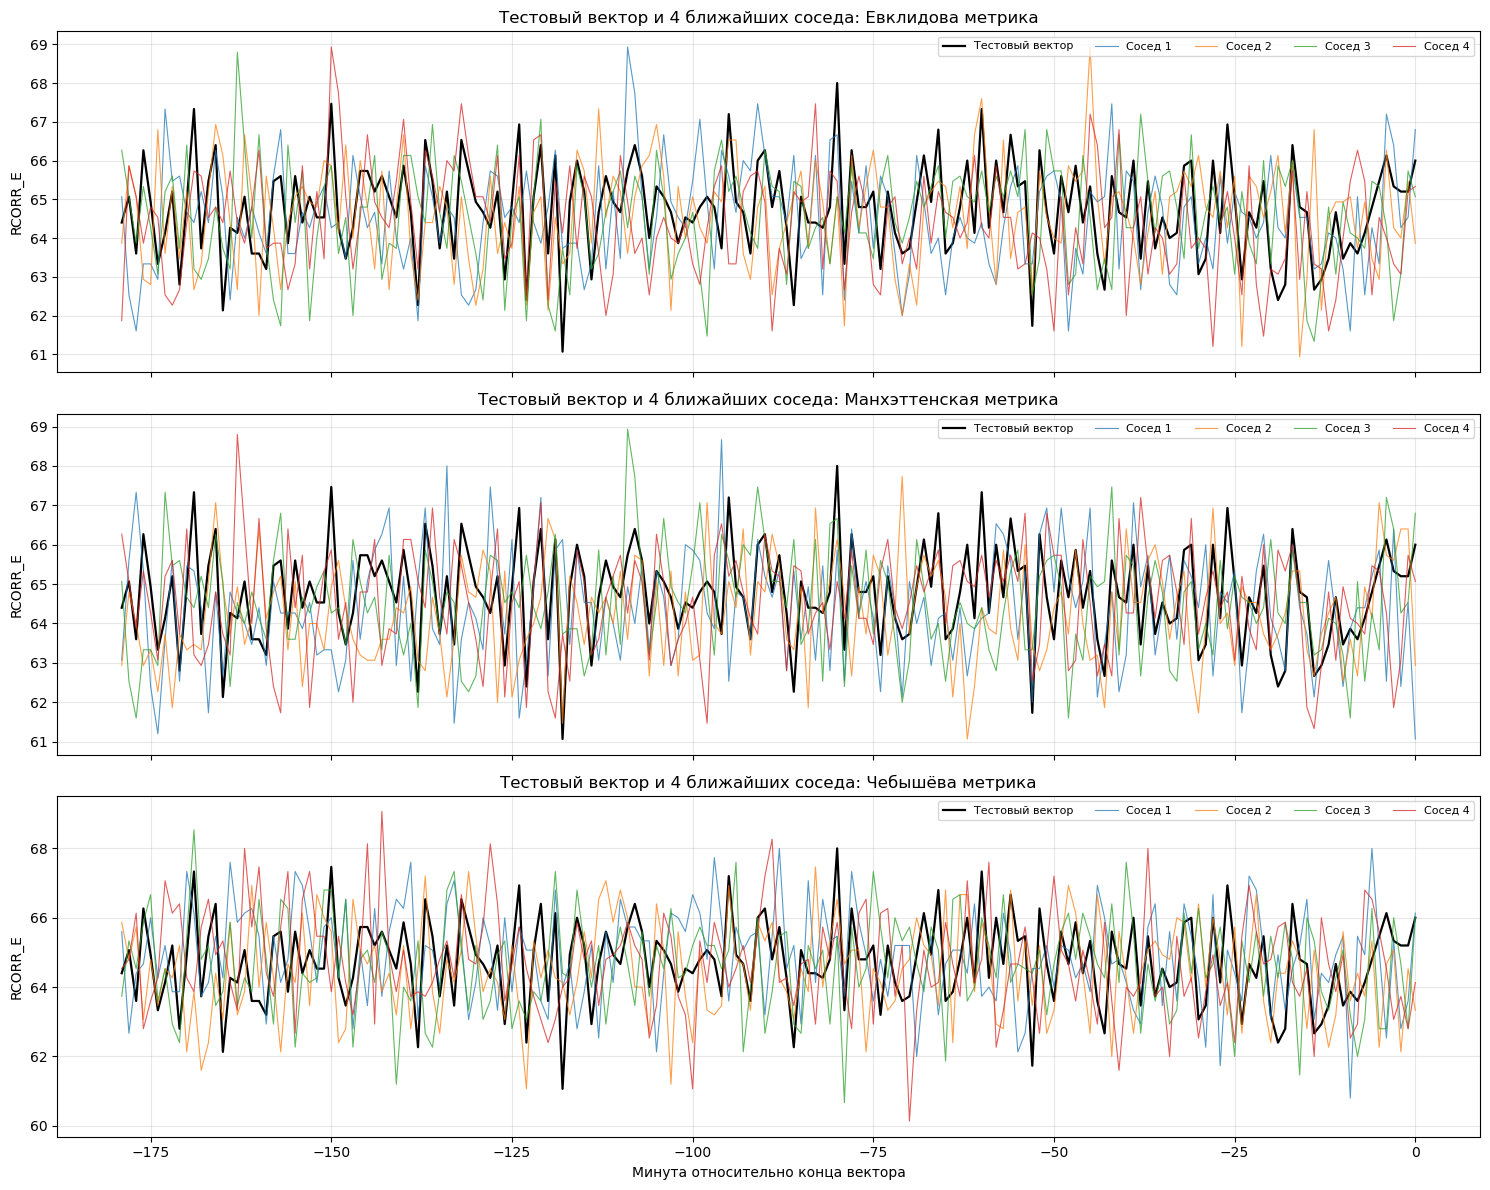

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
relative_time = np.arange(-m + 1, 1)

for ax, (metric_name, selected) in zip(axes, neighbor_indices.items()):
    ax.plot(relative_time, test_vector, color="black", linewidth=1.6, label="Тестовый вектор")
    for rank, selected_index in enumerate(selected, start=1):
        ax.plot(
            relative_time,
            history_vectors[selected_index],
            linewidth=0.8,
            alpha=0.75,
            label=f"Сосед {rank}",
        )
    ax.set_title(f"Тестовый вектор и 4 ближайших соседа: {metric_name} метрика")
    ax.set_ylabel("RCORR_E")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=5, fontsize=8)

axes[-1].set_xlabel("Минута относительно конца вектора")
fig.tight_layout()
fig.savefig(ROOT / "neighbor_profiles.png", dpi=160, bbox_inches="tight")
plt.show()


## Прогноз следующих значений

Для каждой метрики прогноз строится как простое среднее соответствующих следующих значений четырех ближайших соседей.


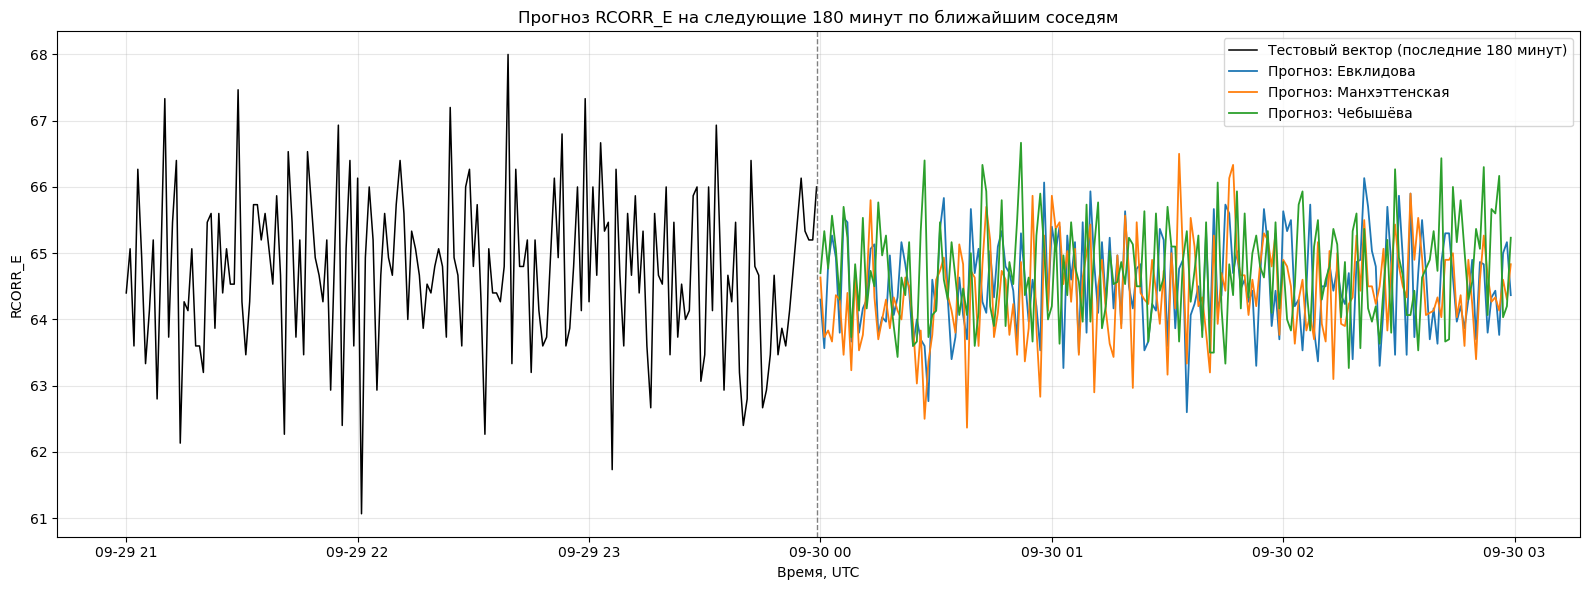

,datetime,Евклидова,Манхэттенская,Чебышёва
0,2015-09-30 00:00:00+00:00,64.300,64.633,64.700
1,2015-09-30 00:01:00+00:00,63.567,63.733,65.333
2,2015-09-30 00:02:00+00:00,64.833,63.833,64.767
3,2015-09-30 00:03:00+00:00,65.267,63.667,65.567
4,2015-09-30 00:04:00+00:00,64.933,64.367,65.066
5,2015-09-30 00:05:00+00:00,63.800,64.300,64.300
6,2015-09-30 00:06:00+00:00,65.534,63.467,65.700
7,2015-09-30 00:07:00+00:00,65.466,64.400,65.233
8,2015-09-30 00:08:00+00:00,63.666,63.233,63.733
9,2015-09-30 00:09:00+00:00,64.666,64.733,64.833


In [17]:
future_index = pd.date_range(
    full_index[-1] + pd.Timedelta(minutes=1),
    periods=forecast_horizon,
    freq="min",
)
prediction_table = pd.DataFrame(
    {
        "datetime": future_index,
        "Евклидова": predictions["Евклидова"],
        "Манхэттенская": predictions["Манхэттенская"],
        "Чебышёва": predictions["Чебышёва"],
    }
)
assert prediction_table.iloc[:, 1:].notna().all().all()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    filled_series.index[-m:],
    filled_series.iloc[-m:],
    color="black",
    linewidth=1.1,
    label="Тестовый вектор (последние 180 минут)",
)
for metric_name, color in [
    ("Евклидова", "tab:blue"),
    ("Манхэттенская", "tab:orange"),
    ("Чебышёва", "tab:green"),
]:
    ax.plot(future_index, predictions[metric_name], color=color, linewidth=1.3, label=f"Прогноз: {metric_name}")

ax.axvline(full_index[-1], color="gray", linestyle="--", linewidth=1)
ax.set_title("Прогноз RCORR_E на следующие 180 минут по ближайшим соседям")
ax.set_xlabel("Время, UTC")
ax.set_ylabel("RCORR_E")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(ROOT / "forecast_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

display(prediction_table.head(10).style.format({
    "Евклидова": "{:.3f}",
    "Манхэттенская": "{:.3f}",
    "Чебышёва": "{:.3f}",
}))


## Выводы

Данные TXBY приведены к непрерывной минутной сетке заполнением только пропусков медианой. Последний 180-минутный фрагмент использован как тестовый вектор. Для трех метрик выбраны по четыре ближайших исторических отрезка, а прогноз на следующие 180 минут получен усреднением фрагментов, следующих за соседями.
